In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, average_precision_score)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib
import warnings
import os
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/mouna_engineered.csv')
print(f"Engineered dataset loaded: {df.shape}")
print(f"High risk rate: {df['high_risk'].mean()*100:.1f}%")

Engineered dataset loaded: (2000, 32)
High risk rate: 14.3%


In [ ]:
# feature columns — exclude target and raw risk score
feature_cols = [c for c in df.columns
                if c not in ['risk_score', 'high_risk']]

X = df[feature_cols].values
y = df['high_risk'].values

# train/test split — stratified to preserve 14.3% positive rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {len(X_train)} ({y_train.sum()} high risk, {y_train.mean()*100:.1f}%)")
print(f"Test size:  {len(X_test)}  ({y_test.sum()} high risk, {y_test.mean()*100:.1f}%)")

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)      # fit on real data only
X_test_scaled  = scaler.transform(X_test)

print(f"\nAfter SMOTE:")
print(f"  Train size:     {len(X_train_sm)}")
print(f"  High risk:      {y_train_sm.sum()} ({y_train_sm.mean()*100:.1f}%)")
print(f"  Low risk:       {(y_train_sm==0).sum()} ({(y_train_sm==0).mean()*100:.1f}%)")

# apply SMOTE to training set only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)  # SMOTE after

print(f"\nFeatures scaled — mean≈0, std≈1")
print(f"Feature count: {X_train_scaled.shape[1]}")

Train size: 1600 (230 high risk, 14.4%)
Test size:  400  (57 high risk, 14.2%)

After SMOTE:
  Train size:     2740
  High risk:      1370 (50.0%)
  Low risk:       1370 (50.0%)

Features scaled — mean≈0, std≈1
Feature count: 30


In [3]:
os.makedirs('../data/models', exist_ok=True)

models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8,
        min_samples_leaf=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4,
        learning_rate=0.05, random_state=42),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=4,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        eval_metric='logloss', verbosity=0),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Training models...\n")
print(f"{'Model':<25} {'CV AUC':>10} {'CV Std':>8} {'Test AUC':>10} {'Test AP':>10}")
print("─"*65)

for name, model in models.items():
    # cross-validation on training set
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train_sm,
        cv=cv, scoring='roc_auc', n_jobs=-1)

    # fit on full training set
    model.fit(X_train_scaled, y_train_sm)

    # test set evaluation
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    test_auc = roc_auc_score(y_test, y_prob)
    test_ap  = average_precision_score(y_test, y_prob)

    results[name] = {
        'model':    model,
        'cv_auc':   cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'test_auc': test_auc,
        'test_ap':  test_ap,
        'y_prob':   y_prob,
    }

    print(f"  {name:<23} {cv_scores.mean():>9.4f} "
          f"{cv_scores.std():>7.4f} "
          f"{test_auc:>9.4f} "
          f"{test_ap:>9.4f}")

# save scaler and feature names
joblib.dump(scaler, '../data/models/scaler.pkl')
joblib.dump(feature_cols, '../data/models/feature_cols.pkl')
print("\nScaler and feature list saved.")

Training models...

Model                         CV AUC   CV Std   Test AUC    Test AP
─────────────────────────────────────────────────────────────────
  Logistic Regression        0.9856  0.0015    0.9714    0.8651
  Random Forest              0.9943  0.0015    0.9490    0.7273
  Gradient Boosting          0.9955  0.0015    0.9584    0.8072
  XGBoost                    0.9959  0.0010    0.9594    0.8165

Scaler and feature list saved.


In [4]:
from sklearn.ensemble import VotingClassifier
from sklearn.base import clone

# ── Ensemble: weighted vote of top 3 models ───────────────
print("Training ensemble model...")

# soft voting ensemble
ensemble = VotingClassifier(
    estimators=[
        ('lr',  clone(models['Logistic Regression'])),
        ('gb',  clone(models['Gradient Boosting'])),
        ('xgb', clone(models['XGBoost'])),
    ],
    voting='soft',
    weights=[3, 2, 2]
)
ensemble.fit(X_train_scaled, y_train_sm)
y_prob_ens = ensemble.predict_proba(X_test_scaled)[:,1]
ens_auc = roc_auc_score(y_test, y_prob_ens)
ens_ap  = average_precision_score(y_test, y_prob_ens)

print(f"  Ensemble Test AUC: {ens_auc:.4f}")
print(f"  Ensemble Test AP:  {ens_ap:.4f}")

# save ensemble
joblib.dump(ensemble, '../data/models/mouna_ensemble.pkl')
print("  Ensemble saved.")

# ── Questionnaire-only vs Full model comparison ───────────
print("\nComparing questionnaire-only vs full model...")

# questionnaire features only (no GGT, ALT, biomarker features)
questionnaire_features = [
    'age', 'bmi', 'age_menarche', 'age_menopause', 'parity',
    'breastfeeding', 'breastfeed_years', 'family_history_1st',
    'family_history_2nd', 'brca_mutation', 'alcohol_drinks_week',
    'smoking', 'physical_activity', 'hrt_use',
    'oral_contraceptive_use', 'prior_benign_biopsy',
    'family_risk_score', 'hormonal_score', 'lifestyle_score',
    'nulliparous', 'age_group', 'bmi_category',
    'age_bmi_interaction', 'reproductive_years'
]

q_idx  = [feature_cols.index(f) for f in questionnaire_features
          if f in feature_cols]

X_train_q = X_train_scaled[:, q_idx]
X_test_q  = X_test_scaled[:,  q_idx]

lr_q = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_q.fit(X_train_q, y_train_sm)
y_prob_q = lr_q.predict_proba(X_test_q)[:,1]
auc_q = roc_auc_score(y_test, y_prob_q)
ap_q  = average_precision_score(y_test, y_prob_q)

print(f"\n  {'Model':<35} {'AUC':>8} {'AP':>8}")
print("  " + "─"*53)
print(f"  {'Questionnaire only':<35} {auc_q:>8.4f} {ap_q:>8.4f}")
print(f"  {'Full model (+ GGT & ALT)':<35} {ens_auc:>8.4f} {ens_ap:>8.4f}")
print(f"  {'AUC improvement':<35} {ens_auc-auc_q:>+8.4f}")
print(f"  {'AP improvement':<35} {ens_ap-ap_q:>+8.4f}")

Training ensemble model...
  Ensemble Test AUC: 0.9695
  Ensemble Test AP:  0.8487
  Ensemble saved.

Comparing questionnaire-only vs full model...

  Model                                    AUC       AP
  ─────────────────────────────────────────────────────
  Questionnaire only                    0.9735   0.8711
  Full model (+ GGT & ALT)              0.9695   0.8487
  AUC improvement                      -0.0039
  AP improvement                       -0.0225


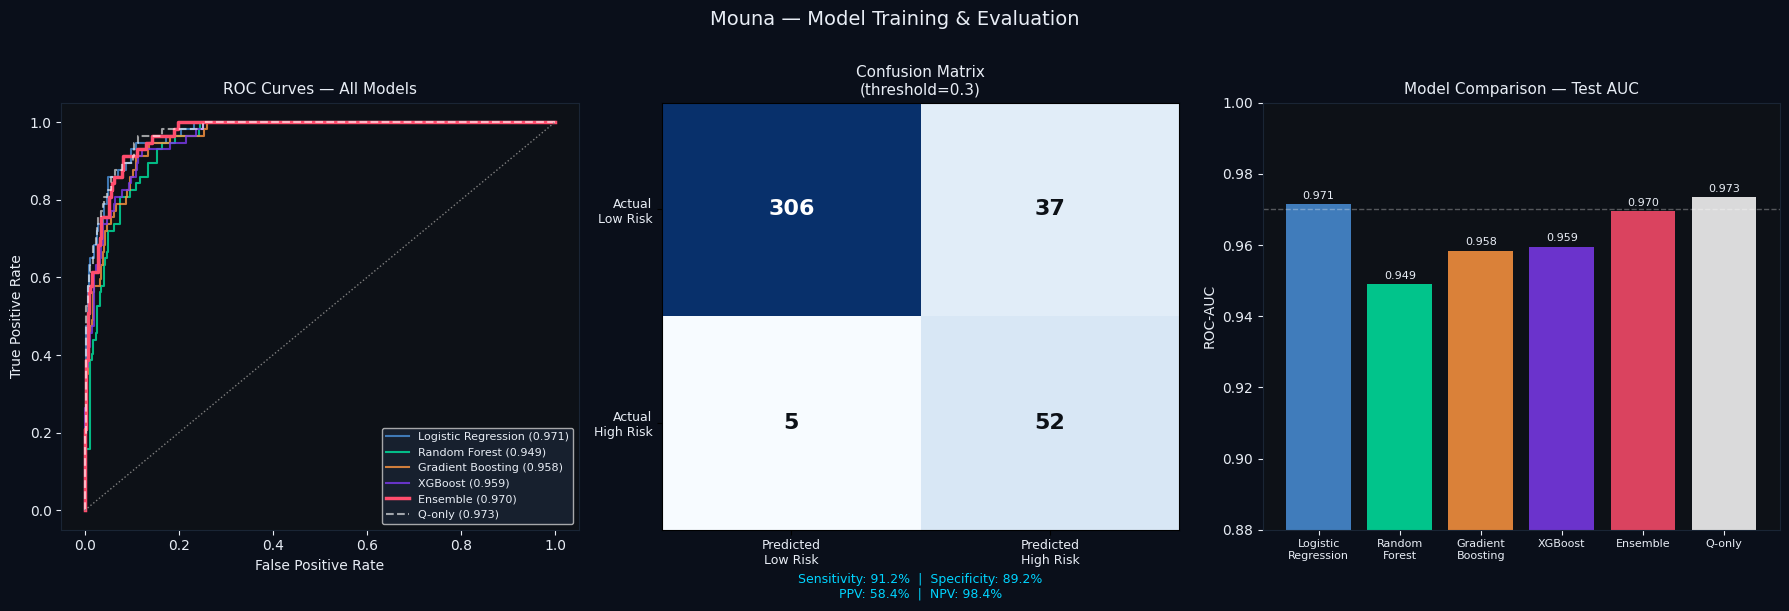


Clinical performance at threshold=0.3:
  Sensitivity (recall): 91.2%
  Specificity:          89.2%
  PPV:                  58.4%
  NPV:                  98.4%

Interpretation:
  Of 57 true high-risk women, Mouna correctly
  identifies 52 (91.2%) for referral.
  5 high-risk women are missed (false negatives).


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0a0f1a')

colors_map = {
    'Logistic Regression': '#4A90D9',
    'Random Forest':       '#00e5a0',
    'Gradient Boosting':   '#ff9640',
    'XGBoost':             '#7c3aed',
    'Ensemble':            '#ff4d6d',
    'Q-only':              '#ffffff',
}

# ── ROC curves ───────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#0d1117')

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=colors_map[name], linewidth=1.5,
            label=f"{name} ({res['test_auc']:.3f})", alpha=0.8)

# ensemble
fpr_e, tpr_e, _ = roc_curve(y_test, y_prob_ens)
ax.plot(fpr_e, tpr_e, color=colors_map['Ensemble'],
        linewidth=2.5, label=f"Ensemble ({ens_auc:.3f})")

# questionnaire only
fpr_q, tpr_q, _ = roc_curve(y_test, y_prob_q)
ax.plot(fpr_q, tpr_q, color=colors_map['Q-only'],
        linewidth=1.5, linestyle='--',
        label=f"Q-only ({auc_q:.3f})", alpha=0.6)

ax.plot([0,1],[0,1], 'gray', linestyle=':', linewidth=1)
ax.set_xlabel('False Positive Rate', color='#e8edf5')
ax.set_ylabel('True Positive Rate', color='#e8edf5')
ax.set_title('ROC Curves — All Models', color='#e8edf5', fontsize=11)
ax.legend(fontsize=8, facecolor='#1a2535', labelcolor='#e8edf5',
          loc='lower right')
ax.tick_params(colors='#e8edf5')
for s in ax.spines.values(): s.set_edgecolor('#1a2535')

# ── Confusion matrix — ensemble ──────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#0d1117')

threshold = 0.3  # lower threshold for higher sensitivity
y_pred = (y_prob_ens >= threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)
im = ax2.imshow(cm, cmap='Blues', aspect='auto')

for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{cm[i,j]}',
                 ha='center', va='center',
                 color='white' if cm[i,j] > cm.max()/2 else '#0d1117',
                 fontsize=16, fontweight='bold')

ax2.set_xticks([0,1])
ax2.set_yticks([0,1])
ax2.set_xticklabels(['Predicted\nLow Risk', 'Predicted\nHigh Risk'],
                     color='#e8edf5', fontsize=9)
ax2.set_yticklabels(['Actual\nLow Risk', 'Actual\nHigh Risk'],
                     color='#e8edf5', fontsize=9)
ax2.set_title(f'Confusion Matrix\n(threshold={threshold})',
              color='#e8edf5', fontsize=11)

tn, fp, fn, tp = cm.ravel()
sensitivity = tp/(tp+fn)*100
specificity = tn/(tn+fp)*100
ppv = tp/(tp+fp)*100 if (tp+fp)>0 else 0
npv = tn/(tn+fn)*100 if (tn+fn)>0 else 0

ax2.set_xlabel(
    f'Sensitivity: {sensitivity:.1f}%  |  Specificity: {specificity:.1f}%\n'
    f'PPV: {ppv:.1f}%  |  NPV: {npv:.1f}%',
    color='#00d4ff', fontsize=9)

# ── Model comparison bar chart ───────────────────────────
ax3 = axes[2]
ax3.set_facecolor('#0d1117')

model_names = list(results.keys()) + ['Ensemble', 'Q-only']
aucs = [results[n]['test_auc'] for n in results.keys()] + [ens_auc, auc_q]
bar_colors = [colors_map.get(n,'#4A90D9') for n in model_names]

bars = ax3.bar(range(len(model_names)), aucs,
               color=bar_colors, alpha=0.85, edgecolor='none')
ax3.set_xticks(range(len(model_names)))
ax3.set_xticklabels(
    [n.replace(' ','\n') for n in model_names],
    color='#e8edf5', fontsize=8)
ax3.set_ylabel('ROC-AUC', color='#e8edf5')
ax3.set_ylim(0.88, 1.0)
ax3.set_title('Model Comparison — Test AUC',
              color='#e8edf5', fontsize=11)
ax3.tick_params(colors='#e8edf5')
ax3.axhline(0.97, color='white', linestyle='--',
            alpha=0.3, linewidth=1)
for s in ax3.spines.values(): s.set_edgecolor('#1a2535')

for bar, auc in zip(bars, aucs):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{auc:.3f}', ha='center', va='bottom',
             color='#e8edf5', fontsize=8)

plt.suptitle('Mouna — Model Training & Evaluation',
             color='#e8edf5', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/model_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0f1a')
plt.show()

print(f"\nClinical performance at threshold={threshold}:")
print(f"  Sensitivity (recall): {sensitivity:.1f}%")
print(f"  Specificity:          {specificity:.1f}%")
print(f"  PPV:                  {ppv:.1f}%")
print(f"  NPV:                  {npv:.1f}%")
print(f"\nInterpretation:")
print(f"  Of {y_test.sum()} true high-risk women, Mouna correctly")
print(f"  identifies {tp} ({sensitivity:.1f}%) for referral.")
print(f"  {fn} high-risk women are missed (false negatives).")